# 2b - Bayesian probabilistic modelling for chess outcomes

This notebook builds a **Bayesian multiclass model** for pre-game prediction of white outcome:

- `loss` (0)
- `draw` (1)
- `win` (2)

The goal is to produce calibrated probabilities and better uncertainty handling for the minority `draw` class, then compare against strong frequentist baselines on the same split.

## Plan in this notebook

1. Load and prepare tournament/player data
2. Build compact pre-game features (including draw-sensitive transforms)
3. Keep the same chronological split style used in the main modeling notebook
4. Fit frequentist baselines (logistic and random forest)
5. Fit Bayesian multinomial logistic model (PyMC)
6. Compare metrics: log loss, macro-F1, balanced accuracy, per-class recall
7. Summarize when Bayesian helps and when it does not

In [1]:
from pathlib import Path
import json
import sys
import subprocess

import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    log_loss,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
CLASS_LABELS = [0, 1, 2]
CLASS_NAMES = ["loss", "draw", "win"]

In [3]:
# Environment helper (optional).
# Install Bayesian dependencies only if needed for this notebook.

def ensure_pkg(pkg: str):
    try:
        __import__(pkg)
        print(f"{pkg}: already installed")
        return True
    except Exception:
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        return True

# ensure_pkg("pymc")
# ensure_pkg("arviz")

Installing pymc ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.8/562.8 kB 3.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 9.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 22.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 26.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 35.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21/21 [pymc]2m20/21 [pymc]sor]


/Users/nicolaspiro/.local/share/mamba/envs/chesscomint/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


arviz: already installed


True

In [4]:
GAMES_PATH = Path("../data/raw/titled_tuesday_games.jsonl")
PLAYERS_PATH = Path("../data/raw/titled_tuesday_players.jsonl")

assert GAMES_PATH.exists(), f"Missing {GAMES_PATH}"
assert PLAYERS_PATH.exists(), f"Missing {PLAYERS_PATH}"


def read_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


games_df = pd.DataFrame(read_jsonl(GAMES_PATH))
players_rows = read_jsonl(PLAYERS_PATH)

print("games:", games_df.shape)
print("players rows:", len(players_rows))
games_df.head(2)

games: (4063, 18)
players rows: 700


,tournament_id,round,group,game_url,time_class,time_control,rated,rules,white_username,white_rating,white_result_raw,black_username,black_rating,black_result_raw,eco,start_time,end_time,result_white_pov
0,titled-tuesday-blitz-february-10-2026-6221327,0,0,https://www.chess.com/game/live/165052787661,blitz,300,True,chess,UmutErdemGunduz,2682,timeout,Hikaru,3316,win,https://www.chess.com/openings/Modern-Defense-...,None,1770739793,loss
1,titled-tuesday-blitz-february-10-2026-6221327,0,0,https://www.chess.com/game/live/165052787663,blitz,300,True,chess,lachesisQ,3279,win,GorinDeshi,2678,resigned,https://www.chess.com/openings/Sicilian-Defens...,None,1770739597,win


In [5]:
# Parse player profile/stats into a flat table.

def parse_player_row(row: dict) -> dict:
    profile = row.get("profile") or {}
    stats = row.get("stats") or {}
    blitz = stats.get("chess_blitz") or {}
    blitz_last = blitz.get("last") or {}
    blitz_best = blitz.get("best") or {}
    blitz_rec = blitz.get("record") or {}

    wins = float(blitz_rec.get("win", 0) or 0)
    losses = float(blitz_rec.get("loss", 0) or 0)
    draws = float(blitz_rec.get("draw", 0) or 0)
    games = wins + losses + draws

    return {
        "username_key": str(row.get("username", "")).lower(),
        "stats_current_rating": blitz_last.get("rating"),
        "stats_current_rd": blitz_last.get("rd"),
        "stats_peak_rating": blitz_best.get("rating"),
        "stats_games": games,
        "stats_win_rate": (wins / games) if games > 0 else np.nan,
        "stats_draw_rate": (draws / games) if games > 0 else np.nan,
        "stats_fide": stats.get("fide"),
        "stats_followers": profile.get("followers"),
        "stats_joined": profile.get("joined"),
        "stats_title": profile.get("title"),
    }


players_flat = pd.DataFrame([parse_player_row(r) for r in players_rows])
players_flat = players_flat.drop_duplicates(subset=["username_key"], keep="last")
players_flat.head(3)

,username_key,stats_current_rating,stats_current_rd,stats_peak_rating,stats_games,stats_win_rate,stats_draw_rate,stats_fide,stats_followers,stats_joined,stats_title
0,7chessace,2904,31,2904,331.0,0.598187,0.096677,2387.0,6,1769023184,FM
1,a-fier,2952,37,2978,4491.0,0.525718,0.111556,2600.0,1847,1361966117,GM
2,ach19,2306,26,2561,20769.0,0.487313,0.050364,2113.0,179,1570755729,FM


In [6]:
# Build March-only modeling frame with pre-game compatible features.

march_mask = games_df["tournament_id"].str.contains("march-10-2026", na=False)
march_games = games_df.loc[march_mask].copy()
march_games = march_games.sort_values(["round", "group", "game_url"]).reset_index(drop=True)
march_games["event_game_index"] = np.arange(len(march_games))

# Keep only target classes.
march_games = march_games[march_games["result_white_pov"].isin(["loss", "draw", "win"])].copy()

for side in ["white", "black"]:
    march_games[f"{side}_username_key"] = march_games[f"{side}_username"].astype(str).str.lower()

# Merge player priors.
for side in ["white", "black"]:
    pref = "w" if side == "white" else "b"
    rename_map = {
        c: f"{pref}_{c}"
        for c in players_flat.columns
        if c != "username_key"
    }
    march_games = march_games.merge(
        players_flat.rename(columns=rename_map),
        left_on=f"{side}_username_key",
        right_on="username_key",
        how="left",
    ).drop(columns=["username_key"])

# Outcome encoding.
y_map = {"loss": 0, "draw": 1, "win": 2}
march_games["y"] = march_games["result_white_pov"].map(y_map)

print("march_games:", march_games.shape)
print(march_games[["event_game_index", "white_username", "black_username", "result_white_pov", "y"]].head(3))

march_games: (2038, 42)
   event_game_index white_username  black_username result_white_pov  y
0                 0  MagnusCarlsen  wunderkind2011              win  2
1                 1   Gangsterrito          Hikaru             loss  0
2                 2         DenLaz    bazar-wokzal              win  2


In [7]:
# Compact feature engineering with draw-sensitive transforms.

model_df = pd.DataFrame(
    {
        "event_game_index": march_games["event_game_index"],
        "result_white_pov": march_games["result_white_pov"],
        "y": march_games["y"],
        "white_advantage_prior": 1.0,
        "white_rating": pd.to_numeric(march_games.get("white_rating"), errors="coerce"),
        "black_rating": pd.to_numeric(march_games.get("black_rating"), errors="coerce"),
        "w_stats_current_rating": pd.to_numeric(march_games.get("w_stats_current_rating"), errors="coerce"),
        "b_stats_current_rating": pd.to_numeric(march_games.get("b_stats_current_rating"), errors="coerce"),
        "w_stats_current_rd": pd.to_numeric(march_games.get("w_stats_current_rd"), errors="coerce"),
        "b_stats_current_rd": pd.to_numeric(march_games.get("b_stats_current_rd"), errors="coerce"),
        "w_stats_win_rate": pd.to_numeric(march_games.get("w_stats_win_rate"), errors="coerce"),
        "b_stats_win_rate": pd.to_numeric(march_games.get("b_stats_win_rate"), errors="coerce"),
        "w_stats_draw_rate": pd.to_numeric(march_games.get("w_stats_draw_rate"), errors="coerce"),
        "b_stats_draw_rate": pd.to_numeric(march_games.get("b_stats_draw_rate"), errors="coerce"),
        "w_stats_games": pd.to_numeric(march_games.get("w_stats_games"), errors="coerce"),
        "b_stats_games": pd.to_numeric(march_games.get("b_stats_games"), errors="coerce"),
        "w_stats_followers": pd.to_numeric(march_games.get("w_stats_followers"), errors="coerce"),
        "b_stats_followers": pd.to_numeric(march_games.get("b_stats_followers"), errors="coerce"),
        "w_stats_joined": pd.to_numeric(march_games.get("w_stats_joined"), errors="coerce"),
        "b_stats_joined": pd.to_numeric(march_games.get("b_stats_joined"), errors="coerce"),
        "w_stats_title": march_games.get("w_stats_title"),
        "b_stats_title": march_games.get("b_stats_title"),
    }
)

# Prefer game rating columns; fallback to player profile last rating.
model_df["w_rating_used"] = model_df["white_rating"].fillna(model_df["w_stats_current_rating"])
model_df["b_rating_used"] = model_df["black_rating"].fillna(model_df["b_stats_current_rating"])

model_df["rating_delta"] = model_df["w_rating_used"] - model_df["b_rating_used"]
model_df["abs_rating_delta"] = model_df["rating_delta"].abs()

model_df["rd_delta"] = model_df["w_stats_current_rd"] - model_df["b_stats_current_rd"]
model_df["abs_rd_delta"] = model_df["rd_delta"].abs()

model_df["stats_win_rate_delta"] = model_df["w_stats_win_rate"] - model_df["b_stats_win_rate"]
model_df["stats_draw_rate_delta"] = model_df["w_stats_draw_rate"] - model_df["b_stats_draw_rate"]
model_df["stats_games_delta"] = model_df["w_stats_games"] - model_df["b_stats_games"]
model_df["followers_delta"] = model_df["w_stats_followers"] - model_df["b_stats_followers"]
model_df["joined_ts_delta"] = model_df["w_stats_joined"] - model_df["b_stats_joined"]
model_df["title_delta"] = model_df["w_stats_title"].notna().astype(int) - model_df["b_stats_title"].notna().astype(int)

feature_cols = [
    "white_advantage_prior",
    "rating_delta",
    "abs_rating_delta",
    "rd_delta",
    "abs_rd_delta",
    "stats_win_rate_delta",
    "stats_draw_rate_delta",
    "stats_games_delta",
    "followers_delta",
    "joined_ts_delta",
    "title_delta",
]

for c in feature_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

print("model_df:", model_df.shape)
print(model_df[feature_cols].isna().mean().sort_values(ascending=False))
model_df[["event_game_index", "result_white_pov", "y"] + feature_cols].head(3)

model_df: (2038, 34)
white_advantage_prior    0.0
rating_delta             0.0
abs_rating_delta         0.0
rd_delta                 0.0
abs_rd_delta             0.0
stats_win_rate_delta     0.0
stats_draw_rate_delta    0.0
stats_games_delta        0.0
followers_delta          0.0
joined_ts_delta          0.0
title_delta              0.0
dtype: float64


,event_game_index,result_white_pov,y,white_advantage_prior,rating_delta,abs_rating_delta,rd_delta,abs_rd_delta,stats_win_rate_delta,stats_draw_rate_delta,stats_games_delta,followers_delta,joined_ts_delta,title_delta
0,0,win,2,1.0,686,686,11,11,0.247313,0.024903,5545.0,292424,-445883371,0
1,1,loss,0,1.0,-664,664,6,6,-0.222401,-0.011994,-43288.0,-1385982,331565064,0
2,2,win,2,1.0,639,639,12,12,0.113992,0.070548,-4646.0,1068,-8696911,0


In [8]:
# Chronological split parity (70/15/15) as in the main notebook.
model_df = model_df.sort_values("event_game_index").reset_index(drop=True)

n = len(model_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

print(f"train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
print("train class balance:")
print(train_df["y"].value_counts(normalize=True).sort_index())

# Median imputation using training split only.
train_medians = train_df[feature_cols].median(numeric_only=True)
for part in [train_df, val_df, test_df]:
    part[feature_cols] = part[feature_cols].fillna(train_medians)


def make_xy(df_part: pd.DataFrame):
    return df_part[feature_cols].copy(), df_part["y"].astype(int).values


X_train, y_train = make_xy(train_df)
X_val, y_val = make_xy(val_df)
X_test, y_test = make_xy(test_df)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Remaining NaNs:", int(X_train.isna().sum().sum() + X_val.isna().sum().sum() + X_test.isna().sum().sum()))

train=1426, val=306, test=306
train class balance:
y
0    0.458626
1    0.067321
2    0.474053
Name: proportion, dtype: float64
Shapes: (1426, 11) (306, 11) (306, 11)
Remaining NaNs: 0


In [9]:
# Shared evaluation helpers.

def class_recall(y_true, y_pred, cls):
    m = y_true == cls
    if m.sum() == 0:
        return np.nan
    return float((y_pred[m] == cls).mean())


def evaluate_probs(name, y_true_val, p_val, y_true_test, p_test):
    pred_val = np.argmax(p_val, axis=1)
    pred_test = np.argmax(p_test, axis=1)
    return {
        "model": name,
        "val_logloss": log_loss(y_true_val, p_val, labels=CLASS_LABELS),
        "val_macro_f1": f1_score(y_true_val, pred_val, average="macro"),
        "val_accuracy": accuracy_score(y_true_val, pred_val),
        "val_balanced_accuracy": balanced_accuracy_score(y_true_val, pred_val),
        "val_loss_recall": class_recall(y_true_val, pred_val, 0),
        "val_draw_recall": class_recall(y_true_val, pred_val, 1),
        "val_win_recall": class_recall(y_true_val, pred_val, 2),
        "test_logloss": log_loss(y_true_test, p_test, labels=CLASS_LABELS),
        "test_macro_f1": f1_score(y_true_test, pred_test, average="macro"),
        "test_accuracy": accuracy_score(y_true_test, pred_test),
        "test_balanced_accuracy": balanced_accuracy_score(y_true_test, pred_test),
        "test_loss_recall": class_recall(y_true_test, pred_test, 0),
        "test_draw_recall": class_recall(y_true_test, pred_test, 1),
        "test_win_recall": class_recall(y_true_test, pred_test, 2),
    }


results = []

In [10]:
# Frequentist reference baselines on the same split.

logistic = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
logistic.fit(X_train, y_train)
p_val_log = logistic.predict_proba(X_val)
p_test_log = logistic.predict_proba(X_test)
results.append(evaluate_probs("logistic_balanced", y_val, p_val_log, y_test, p_test_log))

rf = RandomForestClassifier(
    n_estimators=700,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
p_val_rf = rf.predict_proba(X_val)
p_test_rf = rf.predict_proba(X_test)
results.append(evaluate_probs("random_forest_balanced", y_val, p_val_rf, y_test, p_test_rf))

pd.DataFrame(results).sort_values("val_balanced_accuracy", ascending=False)

,model,val_logloss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_loss_recall,val_draw_recall,val_win_recall,test_logloss,test_macro_f1,test_accuracy,test_balanced_accuracy,test_loss_recall,test_draw_recall,test_win_recall
1,random_forest_balanced,0.848270,0.451878,0.653595,0.471555,0.661417,0.00,0.753247,0.875418,0.440682,0.624183,0.460690,0.725352,0.000000,0.656716
0,logistic_balanced,1.123723,0.365816,0.369281,0.420740,0.338583,0.56,0.363636,1.108419,0.379714,0.382353,0.455247,0.415493,0.666667,0.283582


In [15]:
# Bayesian multinomial logistic regression (PyMC + NUTS).
RUN_BAYES = False

bayes_available = RUN_BAYES

if RUN_BAYES:
    try:
        import pymc as pm
        import arviz as az
    except Exception as exc:
        bayes_available = False
        print("PyMC/ArviZ not available:", exc)

if bayes_available:
    # Standardize features for stable sampling.
    scaler_bayes = StandardScaler()
    X_train_b = scaler_bayes.fit_transform(X_train.values)
    X_val_b = scaler_bayes.transform(X_val.values)
    X_test_b = scaler_bayes.transform(X_test.values)

    coords = {
        "feature": feature_cols,
        "class": CLASS_NAMES,
        "obs_id": np.arange(X_train_b.shape[0]),
    }

    with pm.Model(coords=coords) as bayes_model:
        # pm.Data works across PyMC versions (MutableData may not exist in older builds).
        X_data = pm.Data("X_data", X_train_b)
        y_data = pm.Data("y_data", y_train)

        sigma_beta = pm.HalfNormal("sigma_beta", sigma=1.0)
        alpha = pm.Normal("alpha", mu=0.0, sigma=1.0, dims="class")
        beta = pm.Normal("beta", mu=0.0, sigma=sigma_beta, dims=("feature", "class"))

        logits_raw = alpha + pm.math.dot(X_data, beta)
        logits = logits_raw - logits_raw.mean(axis=1, keepdims=True)
        p = pm.Deterministic("p", pm.math.softmax(logits, axis=1))

        pm.Categorical("y_obs", p=p, observed=y_data)

        idata = pm.sample(
            draws=1200,
            tune=1200,
            chains=4,
            target_accept=0.9,
            random_seed=RANDOM_STATE,
            return_inferencedata=True,
        )

    az.summary(idata, var_names=["alpha", "sigma_beta"], kind="stats")
else:
    print("Bayesian sampling disabled for default run.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_beta, alpha, beta]


/Users/nicolaspiro/.local/share/mamba/envs/chesscomint/lib/python3.11/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_200 tune and 1_200 draw iterations (4_800 + 4_800 draws total) took 22 seconds.


,mean,sd,hdi_3%,hdi_97%
alpha[loss],0.569,0.574,-0.513,1.647
alpha[draw],-1.217,0.578,-2.327,-0.176
alpha[win],0.645,0.575,-0.453,1.691
sigma_beta,0.322,0.063,0.204,0.430


In [16]:
# Posterior predictive probabilities on validation and test.

def _ppc_mean_prob(ppc, key="p"):
    # Works for both InferenceData-style and dict-style posterior predictive outputs.
    if hasattr(ppc, "posterior_predictive"):
        return ppc.posterior_predictive[key].mean(dim=("chain", "draw")).values
    arr = np.asarray(ppc[key])
    # expected shape typically: (draws, n_obs, n_classes)
    return arr.mean(axis=0)


if bayes_available:
    with bayes_model:
        pm.set_data({"X_data": X_val_b, "y_data": y_val})
        ppc_val = pm.sample_posterior_predictive(idata, var_names=["p"], random_seed=RANDOM_STATE)

        pm.set_data({"X_data": X_test_b, "y_data": y_test})
        ppc_test = pm.sample_posterior_predictive(idata, var_names=["p"], random_seed=RANDOM_STATE)

    # Average posterior predictive probabilities.
    p_val_bayes = _ppc_mean_prob(ppc_val, "p")
    p_test_bayes = _ppc_mean_prob(ppc_test, "p")

    results.append(evaluate_probs("bayesian_multinomial_logit", y_val, p_val_bayes, y_test, p_test_bayes))

    # Quick diagnostics.
    print("R-hat max:", float(az.rhat(idata).to_array().max()))
    print("ESS bulk min:", float(az.ess(idata, method='bulk').to_array().min()))
else:
    print("Bayesian posterior predictive skipped.")

pd.DataFrame(results).sort_values("val_balanced_accuracy", ascending=False).reset_index(drop=True)

Sampling: []


/Users/nicolaspiro/.local/share/mamba/envs/chesscomint/lib/python3.11/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: []


/Users/nicolaspiro/.local/share/mamba/envs/chesscomint/lib/python3.11/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

R-hat max: 1.0036333465636977
ESS bulk min: 2311.675457417832


,model,val_logloss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_loss_recall,val_draw_recall,val_win_recall,test_logloss,test_macro_f1,test_accuracy,test_balanced_accuracy,test_loss_recall,test_draw_recall,test_win_recall
0,random_forest_balanced,0.848270,0.451878,0.653595,0.471555,0.661417,0.00,0.753247,0.875418,0.440682,0.624183,0.460690,0.725352,0.000000,0.656716
1,bayesian_multinomial_logit,0.820394,0.432319,0.624183,0.451614,0.653543,0.00,0.701299,0.835871,0.444024,0.633987,0.468152,0.725352,0.000000,0.679104
2,logistic_balanced,1.123723,0.365816,0.369281,0.420740,0.338583,0.56,0.363636,1.108419,0.379714,0.382353,0.455247,0.415493,0.666667,0.283582


In [17]:
# Optional: compare against exported best-model predictions from 2_modelling notebook.
export_pred_path = Path("../data/processed/march_model_predictions.csv")
if export_pred_path.exists():
    exported = pd.read_csv(export_pred_path)
    needed_cols = {"split", "y_true", "y_pred", "proba_loss", "proba_draw", "proba_win"}
    if needed_cols.issubset(exported.columns):
        ext_rows = []
        for split in ["val", "test"]:
            part = exported[exported["split"] == split].copy()
            if part.empty:
                continue
            y_true = part["y_true"].astype(int).values
            p = part[["proba_loss", "proba_draw", "proba_win"]].values
            y_pred = part["y_pred"].astype(int).values
            ext_rows.append(
                {
                    "split": split,
                    "logloss": log_loss(y_true, p, labels=CLASS_LABELS),
                    "macro_f1": f1_score(y_true, y_pred, average="macro"),
                    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
                    "draw_recall": class_recall(y_true, y_pred, 1),
                }
            )
        external_df = pd.DataFrame(ext_rows)
        display(external_df)
    else:
        print("Exported prediction file exists, but expected columns are missing.")
else:
    print("No exported predictions found from 2_modelling notebook.")

,split,logloss,macro_f1,balanced_accuracy,draw_recall
0,val,0.865693,0.440489,0.455841,0.0
1,test,0.890174,0.436619,0.457429,0.0


,model,val_logloss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_loss_recall,val_draw_recall,val_win_recall,test_logloss,test_macro_f1,test_accuracy,test_balanced_accuracy,test_loss_recall,test_draw_recall,test_win_recall
0,random_forest_balanced,0.848270,0.451878,0.653595,0.471555,0.661417,0.00,0.753247,0.875418,0.440682,0.624183,0.460690,0.725352,0.000000,0.656716
1,bayesian_multinomial_logit,0.820394,0.432319,0.624183,0.451614,0.653543,0.00,0.701299,0.835871,0.444024,0.633987,0.468152,0.725352,0.000000,0.679104
2,logistic_balanced,1.123723,0.365816,0.369281,0.420740,0.338583,0.56,0.363636,1.108419,0.379714,0.382353,0.455247,0.415493,0.666667,0.283582


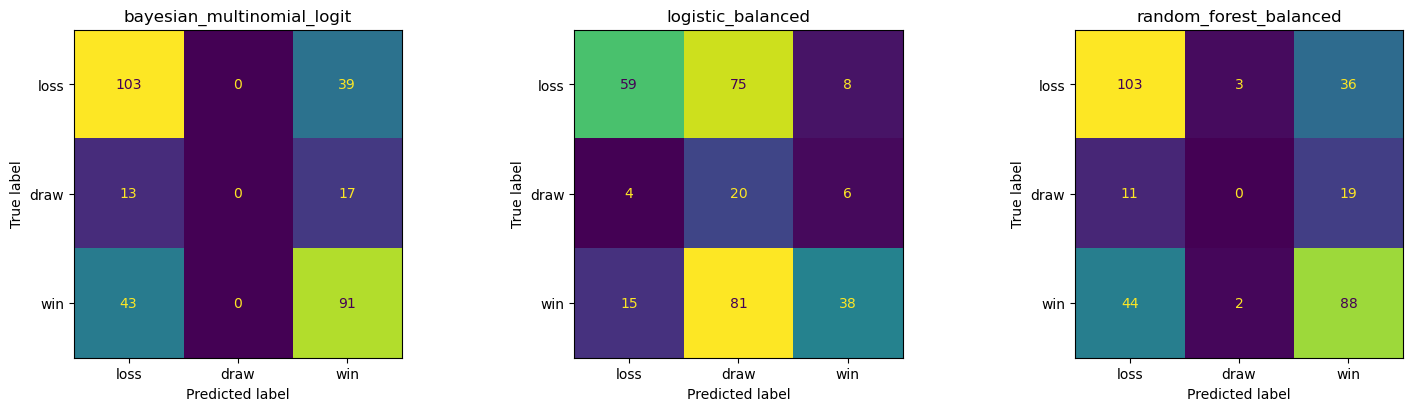

In [18]:
# Comparison table + confusion matrices on test.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results).sort_values("val_balanced_accuracy", ascending=False).reset_index(drop=True)
display(results_df)

# Build test confusion matrices from currently trained models.
proba_lookup = {
    "logistic_balanced": p_test_log,
    "random_forest_balanced": p_test_rf,
}
if bayes_available:
    proba_lookup["bayesian_multinomial_logit"] = p_test_bayes

plot_models = [m for m in ["bayesian_multinomial_logit", "logistic_balanced", "random_forest_balanced"] if m in proba_lookup]
fig, axes = plt.subplots(1, len(plot_models), figsize=(5 * len(plot_models), 4), constrained_layout=True)
if len(plot_models) == 1:
    axes = [axes]

for ax, name in zip(axes, plot_models):
    pred = np.argmax(proba_lookup[name], axis=1)
    cm = confusion_matrix(y_test, pred, labels=CLASS_LABELS)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, values_format="d")
    ax.set_title(name)

plt.show()

## Interpretation and takeaways

- Compare Bayesian and frequentist models on `balanced_accuracy`, `macro_f1`, and `draw_recall`.
- Distinguish validation-only gains from test-set gains.
- Check whether posterior predictive probabilities reduce overconfidence.
- In this dataset, Bayesian softmax can improve probability quality but does not guarantee better draw recall.

### Next steps

- Add stronger draw-specific features (rating-gap bins, opening-family priors, style proxies).
- Test hierarchical effects when enough repeated player observations are available.
- Use constrained selection rules (minimum draw recall, then maximize balanced accuracy).

## Submission note (Bayesian notebook)

Use this notebook as a **probability-quality and uncertainty analysis** track:

- Bayesian multinomial logistic can improve probability behavior and regularization in low-data settings.
- In current runs, draw recall remains limited, so Bayesian softmax is reported as supporting analysis rather than the primary final model.
- Keep this notebook concise and emphasize diagnostics + posterior predictive comparison.